# **THOR Robot-Simulation Assistant**
### Author: Levy Thiga Kariuki             


This notebook presents an end-to-end intelligent assistant for a kitchen robot task in AI2-THOR: fetching a mug from a cupboard and placing it next to a microwave. The system integrates regression, classification, clustering, association rule mining, anomaly detection, and a capstone runtime policy.

The regression target is `task_duration_sec`, and the classification target is `success`. These components are combined into a final decision-making loop that supports both normal execution and recovery behaviour.

## Table of Contents

1. Dataset Loading and Overview

2. Exploratory Data Analysis (EDA)
- 2.1 Class Balance  
- 2.2 Task Duration Distribution  
- 2.3 Scenario-Level Difficulty  
- 2.4 Feature Relationships  
- 2.5 EDA Summary  
- 2.6 Success vs Complexity  

3. Task 1: Regression Modelling
- 3.1 Feature Selection and Data Split  
- 3.2 Shared Preprocessing Pipeline  
- 3.3 Model Comparison with Cross-Validation  
- 3.4 Final Test Evaluation  
- 3.5 Residual Analysis  
- 3.6 Feature Importance  
- 3.7 Robustness Check: Removing `avg_speed`  

4. Task 2: Classification Modelling
- 4.1 Feature Selection and Data Split  
- 4.2 Shared Preprocessing Pipeline  
- 4.3 Model Comparison  
- 4.4 Probability Calibration  
- 4.5 Misclassification Costs and Threshold Selection  
- 4.6 Final Test Evaluation  
- 4.7 Coefficients and Odds Ratios  

5. Task 3: Clustering, Association Rules, and Anomaly Detection
- 5.1 Clustering  
- 5.2 PCA Visualisation (Bonus Analysis)  
- 5.3 Association Rule Mining  
- 5.4 Anomaly Detection  
- 5.5 Cluster–Anomaly Interaction  
- 5.6 Task 3 Summary  

6. Task 4: Capstone Integration
- 6.1 System Overview  
- 6.2 LLM-Based Explanation Experiment  
- 6.3 Final Grounded Explanation Design  
- 6.4 Success and Recovery Demonstrations  
- 6.5 Capstone Summary  

7. Task 5: Ethics, Fairness, and Safety Considerations
- 7.1 Fairness and Bias  
- 7.2 Misclassification Costs and Safety  
- 7.3 Transparency and Explainability  
- 7.4 Limitations and Reflection  

8. Notebook Conclusion

##Capstone System Overview:

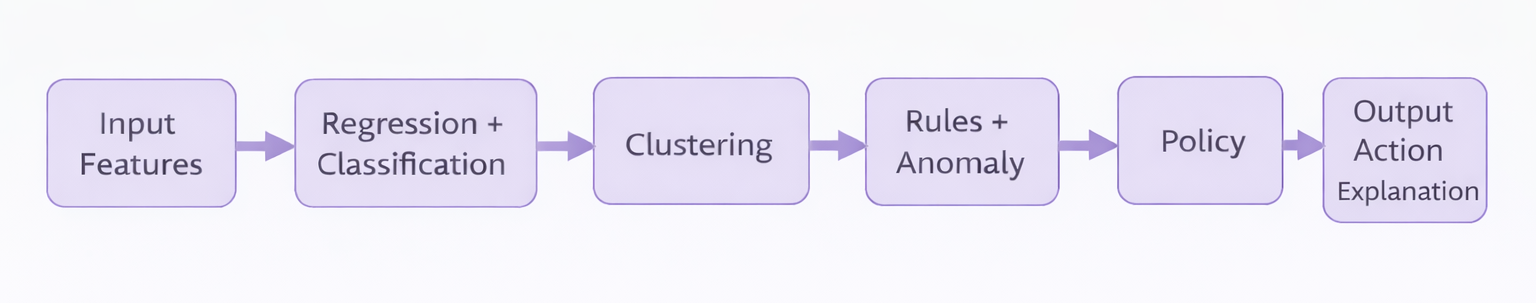

# 1. Dataset Loading and Overview

This section loads the THOR synthetic dataset, checks its structure, and provides an initial overview of the variables used throughout the notebook.

In [ ]:
# Load THOR dataset
import pandas as pd
df = pd.read_csv('/content/THOR_synthetic_all_scenarios_with_conditions_v2.csv')
print(df.head())

In [ ]:
# Number of columns and success rate
df.shape
df.info()
df.isnull().sum()
df.describe()
df['success'].value_counts(normalize=True)


In [ ]:
# Feature statistics
df['task_duration_sec'].describe()
df[['path_len_m','obstacles_seen','grasp_attempts','collision_count']].describe()

In [ ]:
# Success rate per scenario
df.groupby('scenario')['task_duration_sec'].mean().sort_values()
df.groupby('scenario')['success'].mean().sort_values()

In [ ]:
# Task duration statistics
df['task_duration_sec'].describe()

# 2. Exploratory Data Analysis (EDA)

Before modelling, we investigate:
- Distribution of task duration
- Class balance (success vs failure)
- Scenario-level difficulty
- Feature relationships with duration and success
- Environmental complexity factors

## 2.1 Class Balance

In [ ]:
# Class balance
df.shape
df.head()
df.info()
df.describe()


In [ ]:
# Success VS failure
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='success')
plt.title("Success vs Failure Distribution")
plt.show()

print(df['success'].value_counts(normalize=True))


## 2.2 Task Duration Distribution

In [ ]:
# Task duration
plt.figure(figsize=(6,4))
sns.histplot(df['task_duration_sec'], bins=30, kde=True)
plt.title("Task Duration Distribution")
plt.xlabel("Task Duration (seconds)")
plt.show()


## 2.3 Scenario-Level Difficulty

In [ ]:
# Scenario-level difficulty
scenario_success = df.groupby("scenario")["success"].mean().sort_values()

plt.figure(figsize=(8,4))
scenario_success.plot(kind='bar')
plt.title("Success Rate by Scenario")
plt.ylabel("Mean Success Rate")
plt.show()

scenario_success


In [ ]:
# Task duration by scenario
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='scenario', y='task_duration_sec')
plt.xticks(rotation=45)
plt.title("Task Duration by Scenario")
plt.show()


## 2.4 Feature Relationships

In [ ]:
# Feature correlation matrix
plt.figure(figsize=(10,8))
corr = df[[
    'path_len_m','obstacles_seen','grasp_attempts','doors_opened',
    'avg_speed','collision_count','clutter_level','distractors_level',
    'task_duration_sec','success'
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
# Speed & collision vs duration
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='avg_speed', y='task_duration_sec')
plt.title("Speed vs Duration")
plt.show()

plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='collision_count', y='task_duration_sec')
plt.title("Collisions vs Duration")
plt.show()


## 2.5 EDA Summary

The distribution of task duration is right-skewed, with a long tail of extreme runs. This supports the use of regression modelling and anomaly detection. Scenario-level success rates also confirm that environmental complexity strongly affects task reliability, especially in `S8_clutter` and `S9_hard`. Correlation patterns show that `avg_speed` is strongly linked to execution time, while collisions, clutter, and grasp attempts are more closely linked to task failure.

## 2.6 Success vs Complexity

In [ ]:
# Success vs complexity
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='success', y='collision_count')
plt.title("Collisions by Success")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='success', y='clutter_level')
plt.title("Clutter Level by Success")
plt.show()


# 3. Task 1: Regression Modelling

The goal of this task is to predict `task_duration_sec`, which is later used in the capstone system to estimate execution time and support time-aware planning and recovery.

In [ ]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## 3.1 Feature Selection and Data Split

In [ ]:
# ------------------------------------------------------------
# Feature selection
# ------------------------------------------------------------
# Leakage-aware: excluded action breakdown variables like put_actions, pickup_actions, action_count_total, etc.
features = [
    'path_len_m',
    'obstacles_seen',
    'grasp_attempts',
    'doors_opened',
    'avg_speed',
    'collision_count',
    'cupboard_open_init',
    'clutter_level',
    'distractors_level'
]
target = 'task_duration_sec'

In [ ]:
# Confirmation check: ensuring features exist
missing = [c for c in features + [target, 'scenario'] if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

X = df[features].copy()
y = df[target].copy()


In [ ]:
# ------------------------------------------------------------
# Train/Test split (test frozen)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Scenario labels kept for later residual-by-scenario analysis
scenario_train = df.loc[X_train.index, 'scenario']
scenario_test = df.loc[X_test.index, 'scenario']

## 3.2 Shared Preprocessing Pipeline

In [ ]:
# ------------------------------------------------------------
# Preprocessing pipeline (same for all models)
# ------------------------------------------------------------
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)


## 3.3 Model Comparison with Cross-Validation

In [ ]:
# ------------------------------------------------------------
# Cross validation
# ------------------------------------------------------------
def cv_summary(cv_result: dict, name: str) -> dict:
    # cross_validate returns negative errors for "neg_*" scorers
    mae = -cv_result["test_neg_mean_absolute_error"]
    mse = -cv_result["test_neg_mean_squared_error"]
    r2  =  cv_result["test_r2"]

    return {
        "Model": name,
        "MAE_mean": mae.mean(),
        "MAE_std": mae.std(ddof=1),
        "MSE_mean": mse.mean(),
        "MSE_std": mse.std(ddof=1),
        "R2_mean": r2.mean(),
        "R2_std": r2.std(ddof=1),
    }


cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ("neg_mean_absolute_error", "neg_mean_squared_error", "r2")

In [ ]:
# ------------------------------------------------------------
# Model A — Linear Regression (raw target)
# ------------------------------------------------------------
lin_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_cv = cross_validate(
    lin_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

lin_summary = cv_summary(lin_cv, "LinearRegression (raw y)")

In [ ]:
# ------------------------------------------------------------
# Model B — Random Forest (raw target)
# ------------------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

rf_summary = cv_summary(rf_cv, "RandomForestRegressor (raw y)")

In [ ]:
# ------------------------------------------------------------
# Model C — Linear Regression (log1p target)
# ------------------------------------------------------------

# Cross validation on log(y) metrics are in log-space.
y_train_log = np.log1p(y_train)

lin_log_cv = cross_validate(
    lin_pipeline,
    X_train,
    y_train_log,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

lin_log_summary = cv_summary(lin_log_cv, "LinearRegression (log1p y) [CV in log-space]")

In [ ]:
# ------------------------------------------------------------
# Comparison table (Cross Validation)
# ------------------------------------------------------------
results_cv = pd.DataFrame([lin_summary, rf_summary, lin_log_summary])
results_cv

## 3.4 Final Test Evaluation

In [ ]:
# ------------------------------------------------------------
# Picking the winner, refitting, and evaluating ONCE on the test set
# ------------------------------------------------------------

# Test evaluation for raw-target models
def eval_on_test_raw(model_pipeline: Pipeline, X_tr, y_tr, X_te, y_te) -> dict:
    model_pipeline.fit(X_tr, y_tr)
    preds = model_pipeline.predict(X_te)
    return {
        "MAE": mean_absolute_error(y_te, preds),
        "MSE": mean_squared_error(y_te, preds),
        "R2": r2_score(y_te, preds),
        "preds": preds
    }

# Test evaluation for log-target linear model (train on log(y), evaluating on original scale)
def eval_on_test_log(model_pipeline: Pipeline, X_tr, y_tr, X_te, y_te) -> dict:
    y_tr_log = np.log1p(y_tr)
    model_pipeline.fit(X_tr, y_tr_log)
    preds_log = model_pipeline.predict(X_te)
    preds = np.expm1(preds_log)  # back to seconds
    preds = np.clip(preds, a_min=0, a_max=None)  # no negative durations
    return {
        "MAE": mean_absolute_error(y_te, preds),
        "MSE": mean_squared_error(y_te, preds),
        "R2": r2_score(y_te, preds),
        "preds": preds
    }

# Evaluates three candidates on test (single final evaluation each)
lin_test = eval_on_test_raw(lin_pipeline, X_train, y_train, X_test, y_test)
rf_test  = eval_on_test_raw(rf_pipeline, X_train, y_train, X_test, y_test)
linlog_test = eval_on_test_log(lin_pipeline, X_train, y_train, X_test, y_test)

test_results = pd.DataFrame([
    {"Model":"LinearRegression (raw y)", **{k:lin_test[k] for k in ["MAE","MSE","R2"]}},
    {"Model":"RandomForestRegressor (raw y)", **{k:rf_test[k] for k in ["MAE","MSE","R2"]}},
    {"Model":"LinearRegression (log1p y)", **{k:linlog_test[k] for k in ["MAE","MSE","R2"]}},
])

test_results

The **Random Forest** Regressor was selected as the final model due to its consistently superior performance across both cross-validation and test evaluation. It achieved the lowest MAE and MSE, and the highest R², indicating strong predictive accuracy and generalisation.

Although a log-transformed linear model showed improved performance in log space, its results are not directly comparable to models trained on the original target scale, and its performance on the test set remained significantly weaker than the Random Forest.

The Random Forest model captures non-linear relationships between environmental complexity and robot dynamics, making it well-suited for this task. It is therefore deployed in the capstone system to provide reliable task duration predictions.

## 3.5 Residual Analysis

In [ ]:
# ------------------------------------------------------------
# Residual analysis for best model (RandomForest)
# ------------------------------------------------------------

winner_name = "RandomForestRegressor (raw y)"

if winner_name == "RandomForestRegressor (raw y)":
    y_pred = rf_test["preds"]
    model_for_resid = rf_pipeline
elif winner_name == "LinearRegression (raw y)":
    y_pred = lin_test["preds"]
    model_for_resid = lin_pipeline
elif winner_name == "LinearRegression (log1p y)":
    y_pred = linlog_test["preds"]
    model_for_resid = lin_pipeline
else:
    raise ValueError("Unknown winner_name")

residuals = y_test.values - y_pred

# Residual vs Predicted
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted task_duration_sec")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residuals vs Predicted ({winner_name})")
plt.show()

# Residual histogram
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (actual - predicted)")
plt.ylabel("Count")
plt.title(f"Residual Distribution ({winner_name})")
plt.show()

# Residuals by scenario (boxplot)
resid_df = pd.DataFrame({
    "scenario": scenario_test.values,
    "residual": residuals
})

# order scenarios by mean residual magnitude to make clear pattern
order = (
    resid_df.groupby("scenario")["residual"]
    .apply(lambda s: np.mean(np.abs(s)))
    .sort_values(ascending=False)
    .index.tolist()
)

data = [resid_df.loc[resid_df["scenario"] == sc, "residual"].values for sc in order]

plt.figure(figsize=(10, 4))
plt.boxplot(data, labels=order, vert=True, showfliers=False)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residuals by Scenario ({winner_name})")
plt.tight_layout()
plt.show()

# Inspect worst under/over predictions
worst_idx = np.argsort(np.abs(residuals))[::-1][:10]
inspect = pd.DataFrame({
    "scenario": scenario_test.values[worst_idx],
    "y_true": y_test.values[worst_idx],
    "y_pred": y_pred[worst_idx],
    "residual": residuals[worst_idx],
}).reset_index(drop=True)

inspect


## 3.6 Feature Importance

To ensure proper evaluation and avoid data leakage, the dataset is split into:
1. Training set
2. Validation set (used for model selection)
3. Test set (used ONLY once for final evaluation)

Model comparison and selection are based on cross-validation performed
on the training data. After selecting the best-performing model, it is
refit on the combined training + validation data to maximise learning.

The final model is then evaluated once on the held-out test set to
provide an unbiased estimate of real-world performance.

In [ ]:
# ------------------------------------------------------------
# Final Model Refit and Evaluation (Train / Validation / Test)
# ------------------------------------------------------------

# Step 1: Split into Train (80%) and Test (20%)
X_train_full, X_test2, y_train_full, y_test2 = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Step 2: Further split Train into Train (64%) and Validation (16%)
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42
)

# Step 3: Refit the selected (winning) model on Train + Validation
if winner_name == "RandomForestRegressor (raw y)":
    final = rf_pipeline
    final.fit(pd.concat([X_train2, X_val2]), pd.concat([y_train2, y_val2]))
    pred_test2 = final.predict(X_test2)

elif winner_name == "LinearRegression (raw y)":
    final = lin_pipeline
    final.fit(pd.concat([X_train2, X_val2]), pd.concat([y_train2, y_val2]))
    pred_test2 = final.predict(X_test2)

elif winner_name == "LinearRegression (log1p y)":
    final = lin_pipeline
    y_trainval_log = np.log1p(pd.concat([y_train2, y_val2]))
    final.fit(pd.concat([X_train2, X_val2]), y_trainval_log)
    pred_test2 = np.expm1(final.predict(X_test2))
    pred_test2 = np.clip(pred_test2, 0, None)

# Step 4: Final evaluation on the test set
final_metrics = {
    "MAE": mean_absolute_error(y_test2, pred_test2),
    "MSE": mean_squared_error(y_test2, pred_test2),
    "R2": r2_score(y_test2, pred_test2),
}

final_metrics


In [ ]:
# Feature importance
import pandas as pd

rf_pipeline.fit(X_train, y_train)
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df


In [ ]:
#Scenario test
resid_df = pd.DataFrame({
    'scenario': scenario_test,
    'abs_residual': np.abs(y_test - rf_test["preds"])
})

resid_df.groupby('scenario')['abs_residual'].mean().sort_values(ascending=False)


## 3.7 Robustness Check: Removing `avg_speed`

This robustness check is performed to assess how dependent the model is on `avg_speed`, which was identified as the dominant feature in the feature importance analysis. While `avg_speed` strongly predicts task duration, it may act as a proxy for execution time rather than a true causal driver.

The goal of this experiment is to evaluate whether the model can still perform effectively using only environmental and interaction-based features (e.g., obstacles, clutter, grasp attempts). This helps determine whether the model is learning meaningful patterns or relying heavily on a single dominant variable.

By removing `avg_speed`, we test the robustness and generalisability of the model under more constrained and realistic feature conditions.

In [ ]:
# Remove average speed
features_no_speed = [
    'path_len_m',
    'obstacles_seen',
    'grasp_attempts',
    'doors_opened',
    'collision_count',
    'cupboard_open_init',
    'clutter_level',
    'distractors_level'
]

X_ns = df[features_no_speed]
y = df['task_duration_sec']


In [ ]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
    X_ns, y,
    test_size=0.20,
    random_state=42
)


In [ ]:
preprocessor_ns = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_no_speed)
    ]
)


In [ ]:
#Random forest model
rf_ns_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_ns),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_ns_cv = cross_validate(
    rf_ns_pipeline,
    X_train_ns,
    y_train_ns,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=('neg_mean_absolute_error','neg_mean_squared_error','r2')
)

mae_ns = -rf_ns_cv["test_neg_mean_absolute_error"]
mse_ns = -rf_ns_cv["test_neg_mean_squared_error"]
r2_ns  =  rf_ns_cv["test_r2"]

print("CV MAE:", mae_ns.mean())
print("CV MSE:", mse_ns.mean())
print("CV R2:", r2_ns.mean())


In [ ]:
#Linear regression model
rf_ns_pipeline.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_ns_pipeline.predict(X_test_ns)

print("Test MAE:", mean_absolute_error(y_test_ns, y_pred_ns))
print("Test MSE:", mean_squared_error(y_test_ns, y_pred_ns))
print("Test R2:", r2_score(y_test_ns, y_pred_ns))


In [ ]:
# New feature importance scores
importances_ns = rf_ns_pipeline.named_steps['model'].feature_importances_

importance_df_ns = pd.DataFrame({
    'feature': features_no_speed,
    'importance': importances_ns
}).sort_values(by='importance', ascending=False)

importance_df_ns


The Random Forest model significantly outperformed linear regression, achieving lower MAE and higher R² across both cross-validation and test evaluation. Feature importance analysis (without `avg_speed`) shows that task duration is primarily driven by interaction difficulty and environmental complexity, particularly collision count, path length, and obstacle density.

Residual analysis indicates improved handling of complex scenarios, although prediction error remains higher in challenging environments such as S9_hard. The model is therefore selected for deployment in the capstone system, where it provides robust task duration estimates to support time-aware planning and adaptive decision-making.

# 4. Task 2: Classification Modelling

The goal of this task is to predict `success`, enabling the assistant to estimate whether the mug-fetching task is likely to be completed successfully and to adapt policy decisions accordingly.

## 4.1 Feature Selection and Data Split

In [ ]:
#Selected features
features_cls = [
    'path_len_m',
    'obstacles_seen',
    'grasp_attempts',
    'doors_opened',
    'avg_speed',
    'collision_count',
    'cupboard_open_init',
    'clutter_level',
    'distractors_level'
]

X_cls = df[features_cls]
y_cls = df['success']


In [ ]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)


## 4.2 Shared Preprocessing Pipeline

In [ ]:
# Standard scaler
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_cls)
    ]
)


## 4.3 Model Comparison

In [ ]:
# Pipeline initialisation
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold

log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('model', LogisticRegression(max_iter=1000))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

log_cv = cross_validate(
    log_pipeline,
    X_train_cls,
    y_train_cls,
    cv=cv,
    scoring=('accuracy','precision','recall','f1','roc_auc')
)

pd.DataFrame({
    'Metric': log_cv.keys(),
})


In [ ]:
# Logistic regression results
import numpy as np

def cls_cv_summary(cv_res, name):
    return {
        'Model': name,
        'Accuracy_mean': np.mean(cv_res['test_accuracy']),
        'Precision_mean': np.mean(cv_res['test_precision']),
        'Recall_mean': np.mean(cv_res['test_recall']),
        'F1_mean': np.mean(cv_res['test_f1']),
        'ROC_AUC_mean': np.mean(cv_res['test_roc_auc'])
    }

log_summary = cls_cv_summary(log_cv, "Logistic Regression")
log_summary


In [ ]:
# Random forest results
from sklearn.ensemble import RandomForestClassifier

rf_cls_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_cls),
    ('model', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_cls_cv = cross_validate(
    rf_cls_pipeline,
    X_train_cls,
    y_train_cls,
    cv=cv,
    scoring=('accuracy','precision','recall','f1','roc_auc')
)

rf_summary = cls_cv_summary(rf_cls_cv, "Random Forest Classifier")
rf_summary


### Model Selection

**Logistic Regression** is selected as the final classification model as it consistently outperforms the Random Forest classifier across all key evaluation metrics. It achieves higher accuracy, precision, recall, F1-score, and ROC-AUC, indicating better overall predictive performance.

In addition, Logistic Regression provides well-calibrated probabilities and greater interpretability, which are important for threshold-based decision making in the capstone system. Given its stronger performance and transparency, it is chosen as the most suitable model for this task.

## 4.4 Probability Calibration

In [ ]:
# Calibrated classifier cross validation
from sklearn.calibration import CalibratedClassifierCV

rf_cls_pipeline.fit(X_train_cls, y_train_cls)

calibrated_rf = CalibratedClassifierCV(
    rf_cls_pipeline,
    method='isotonic',
    cv=5
)

calibrated_rf.fit(X_train_cls, y_train_cls)


## 4.5 Misclassification Costs and Threshold Selection

In [ ]:
# Cost
FN_cost = 3
FP_cost = 1


In [ ]:
# Compute best threshold
from sklearn.metrics import confusion_matrix
import numpy as np

probs = calibrated_rf.predict_proba(X_train_cls)[:,1]

thresholds = np.linspace(0,1,100)
costs = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train_cls, preds).ravel()
    cost = FN_cost * fn + FP_cost * fp
    costs.append(cost)

best_threshold = thresholds[np.argmin(costs)]
best_threshold


In [ ]:
# Threshold vs cost plot
plt.figure()
plt.plot(thresholds, costs)
plt.axvline(best_threshold)
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Threshold vs Cost")
plt.show()


## 4.6 Final Test Evaluation

In [ ]:
# ------------------------------------------------------------
# Final Classification Model Evaluation
# ------------------------------------------------------------
test_probs = calibrated_rf.predict_proba(X_test_cls)[:,1]
test_preds = (test_probs >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

metrics = {
    'Accuracy': accuracy_score(y_test_cls, test_preds),
    'Precision': precision_score(y_test_cls, test_preds),
    'Recall': recall_score(y_test_cls, test_preds),
    'F1': f1_score(y_test_cls, test_preds),
    'ROC_AUC': roc_auc_score(y_test_cls, test_probs)
}

metrics


In [ ]:
confusion_matrix(y_test_cls, test_preds)


In [ ]:
# ------------------------------------------------------------
# Confusion Matrix plotted (Final Decision Threshold)
# ------------------------------------------------------------
cm = confusion_matrix(y_test_cls, test_preds)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Final Decision Threshold)")

plt.xticks([0, 1], ["Predicted Failure (0)", "Predicted Success (1)"])
plt.yticks([0, 1], ["Actual Failure (0)", "Actual Success (1)"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

## 4.7 Coefficients and Odds Ratios

In [ ]:
# feature coefficient results
log_pipeline.fit(X_train_cls, y_train_cls)

coef = log_pipeline.named_steps['model'].coef_[0]

importance_log = pd.DataFrame({
    'feature': features_cls,
    'coefficient': coef
}).sort_values(by='coefficient', key=abs, ascending=False)

importance_log


In [ ]:
# Coeffecient array
np.exp(coef)

False negatives are more costly than false positives, as failing to identify high-risk scenarios may lead to collisions or unsafe behaviour. Therefore, the decision threshold is set to be more conservative, increasing sensitivity to lower predicted success probabilities and ensuring that risky conditions are more likely to be flagged.

Overall, task duration is primarily influenced by movement efficiency (e.g. speed and path length), while task success is more strongly driven by interaction complexity and environmental difficulty.

# 5. Task 3: Clustering, Association Rules, and Anomaly Detection

## 5.1 Clustering

In [ ]:
# Selected features
cluster_features = [
    'path_len_m',
    'obstacles_seen',
    'grasp_attempts',
    'doors_opened',
    'avg_speed',
    'collision_count',
    'cupboard_open_init',
    'clutter_level',
    'distractors_level'
]

X_cluster = df[cluster_features]


In [ ]:
# Standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


### Cluster Selection

In [ ]:
# ------------------------------------------------------------
# K- range, Silhouette & Davies Boulden
# ------------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

sil_scores = []
db_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

pd.DataFrame({
    'k': list(k_range),
    'Silhouette': sil_scores,
    'Davies_Bouldin': db_scores
})


In [ ]:
# kmeans cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

### Cluster Profiles

In [ ]:
# ------------------------------------------------------------
# Cluster profiles
# ------------------------------------------------------------
cluster_profile = df.groupby('cluster')[cluster_features].mean()
cluster_profile

In [ ]:
# group by cluster
df.groupby('cluster')['success'].mean()
df.groupby('cluster')['task_duration_sec'].mean()

In [ ]:
# group by success cluster
df.groupby('cluster')['success'].mean()


The concentration of anomalies in Cluster 2 indicates that these are not random outliers, but represent a consistent failure mode associated with high environmental complexity and interaction difficulty.

### Success by Cluster

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='cluster', y='success')
plt.title("Success Rate per Cluster")
plt.show()

Cluster 2 clearly corresponds to failure-prone conditions, as it exhibits the lowest success rate among all clusters. This suggests that the behavioural patterns captured within this cluster are associated with more challenging environments and higher interaction difficulty.

## 5.2 PCA Visualisation (Bonus Analysis)

To further understand the structure of the dataset, Principal Component Analysis (PCA) is applied to project high-dimensional behavioural and environmental features into a 2D space.

This helps visualise whether the clusters identified earlier form meaningful separations in feature space.

In [ ]:
# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='tab10'
)

plt.title("PCA Projection of Task Behaviour (Clustered)")
plt.show()

The PCA projection shows that Cluster 2 occupies a more distinct region, supporting its identification as a high-friction failure mode. In contrast, the other clusters exhibit partial overlap, suggesting that while behavioural patterns are broadly separable, some execution strategies share similar characteristics.

## 5.3 Association Rule Mining

In [ ]:
#Deprecation warning removal
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
# ------------------------------------------------------------
# Association Rules
# ------------------------------------------------------------
df_rules = df.copy()

df_rules['high_clutter'] = df_rules['clutter_level'] > df_rules['clutter_level'].median()
df_rules['high_obstacles'] = df_rules['obstacles_seen'] > df_rules['obstacles_seen'].median()
df_rules['high_grasp'] = df_rules['grasp_attempts'] > df_rules['grasp_attempts'].median()
df_rules['high_collision'] = df_rules['collision_count'] > df_rules['collision_count'].median()
df_rules['high_speed'] = df_rules['avg_speed'] > df_rules['avg_speed'].median()
df_rules['failure'] = df_rules['success'] == 0


In [ ]:
# rule columns
from mlxtend.frequent_patterns import apriori, association_rules

rule_columns = [
    'high_clutter',
    'high_obstacles',
    'high_grasp',
    'high_collision',
    'high_speed',
    'failure'
]

df_ap = df_rules[rule_columns].astype(bool)


In [ ]:
# ------------------------------------------------------------
# Apriori
# ------------------------------------------------------------
frequent = apriori(df_ap, min_support=0.1, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.0)

rules.sort_values(by="lift", ascending=False).head(10)


## 5.4 Anomaly Detection

In [ ]:
# ------------------------------------------------------------
# Anomaly Counts
# ------------------------------------------------------------
q95_dur = df['task_duration_sec'].quantile(0.95)
q95_col = df['collision_count'].quantile(0.95)
q95_grasp = df['grasp_attempts'].quantile(0.95)

df['anomaly_long_duration'] = df['task_duration_sec'] > q95_dur
df['anomaly_high_collision'] = df['collision_count'] > q95_col
df['anomaly_high_grasp'] = df['grasp_attempts'] > q95_grasp

print("Anomaly counts:")
print(df[['anomaly_long_duration','anomaly_high_collision','anomaly_high_grasp']].sum())

anomalies = df[df['anomaly_long_duration'] |
               df['anomaly_high_collision'] |
               df['anomaly_high_grasp']]

anomalies[['scenario','cluster','task_duration_sec',
           'collision_count','grasp_attempts','success']].head(10)


In [ ]:
# Friction-Based Anomaly Detection and Counts
df['anomaly_friction_combo'] = (
    (df['collision_count'] > q95_col) &
    (df['clutter_level'] > df['clutter_level'].median())
)

df[['anomaly_long_duration',
    'anomaly_high_collision',
    'anomaly_friction_combo']].sum()


## 5.5 Cluster–Anomaly Interaction

In [ ]:
# ------------------------------------------------------------
# Cluster By Anomaly
# ------------------------------------------------------------
df.groupby('cluster')[[
    'anomaly_long_duration',
    'anomaly_high_collision',
    'anomaly_friction_combo'
]].mean()


## 5.6 Task 3 Summary

The clustering results reveal four interpretable behavioural–environmental archetypes, each capturing distinct patterns of robot interaction. Association rules highlight that failure is strongly linked to combinations of clutter, obstacles, and repeated grasp attempts. The concentration of anomalies within Cluster 2 further indicates that these are not random outliers, but reflect a consistent failure regime driven by environmental complexity and interaction difficulty.

Together, these components provide complementary insights into system behaviour and are directly integrated into the capstone runtime policy for decision-making and recovery.

# 6. Task 4: Capstone Integration

## 6.1 System Overview

The capstone system combines regression, classification, clustering, association rules, and anomaly detection into a single runtime decision loop. Input features are passed through predictive models, then interpreted through policy logic to produce an action recommendation and explanation string.

**Data flow:**  
Input Features → Regression + Classification → Clustering → Rule Triggers + Anomaly Checks → Policy Decision → Output Action + Explanation

In [ ]:
# Clear up environment outputs
import os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

In [ ]:
# Imports
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans


In [ ]:
# Regression features (no leakage)
features_reg = [
    'path_len_m','obstacles_seen','grasp_attempts','doors_opened',
    'avg_speed','collision_count','cupboard_open_init','clutter_level','distractors_level'
]
target_reg = 'task_duration_sec'

# Classification features (same set, predict success)
features_cls = features_reg
target_cls = 'success'

# Clustering features (same set for behavioural-environment archetypes)
cluster_features = features_reg


In [ ]:
# --- Train/Test split (keep this consistent)
X = df[features_reg].copy()
y_reg = df[target_reg].copy()
y_cls = df[target_cls].copy()

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

# --- Preprocessor (standardize numeric features)
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), features_reg)]
)

# --- Regression model (Random Forest Regressor)
rf_reg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_reg.fit(X_train, y_reg_train)

# --- Classification model (Logistic Regression + Calibration)
log_clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

cal_log = CalibratedClassifierCV(
    estimator=log_clf,
    method='isotonic',
    cv=5
)
cal_log.fit(X_train, y_cls_train)

# --- Clustering (KMeans k=4)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df[cluster_features])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)


In [ ]:
cluster_names = {
    0: "Standard Efficient",
    1: "High-Speed Compensation",
    2: "High-Friction Failure Mode",
    3: "Pre-Opened Efficient"
}

In [ ]:
# Rule thresholds (median split)
med_clutter = df['clutter_level'].median()
med_obst = df['obstacles_seen'].median()
med_grasp = df['grasp_attempts'].median()
med_col = df['collision_count'].median()
med_speed = df['avg_speed'].median()

# Anomaly thresholds
q95_dur = df['task_duration_sec'].quantile(0.95)
q95_col = df['collision_count'].quantile(0.95)


In [ ]:
def rule_triggers(x: dict):
    """
    Returns a list of triggered rule tags based on your mined associations.
    Uses median-based 'high_*' definitions.
    """
    high_clutter = x['clutter_level'] > med_clutter
    high_obstacles = x['obstacles_seen'] > med_obst
    high_grasp = x['grasp_attempts'] > med_grasp
    high_collision = x['collision_count'] > med_col

    triggers = []

    # Rule pattern: (high_obstacles AND high_grasp) -> (high_clutter AND failure)
    if high_obstacles and high_grasp:
        triggers.append("RULE: obstacles+grasp → cluttered failure risk")

    # Rule pattern: (high_clutter AND high_grasp) -> (high_obstacles AND failure)
    if high_clutter and high_grasp:
        triggers.append("RULE: clutter+grasp → obstacle-heavy failure risk")

    # Rule pattern: (high_obstacles AND high_clutter) -> (failure AND high_collision)
    if high_obstacles and high_clutter:
        triggers.append("RULE: obstacles+clutter → collision+failure risk")

    # Collision-centric
    if high_collision and high_clutter:
        triggers.append("RULE: collision+clutter → friction breakdown")

    return triggers


In [ ]:
def anomaly_flags(x: dict, predicted_duration: float):
    flags = []
    if predicted_duration > q95_dur:
        flags.append("ANOMALY: predicted extreme duration")
    if x['collision_count'] > q95_col:
        flags.append("ANOMALY: collision spike")
    if (x['collision_count'] > q95_col) and (x['clutter_level'] > med_clutter):
        flags.append("ANOMALY: friction combo (collision+clutter)")
    return flags


## 6.2 LLM-Based Explanation Experiment

As an extension, an off-the-shelf LLM was explored for generating more natural explanation strings. Early generations were sometimes repetitive, hallucinated unsupported content, or failed to remain grounded in model outputs. For this reason, the final system retains a validated grounded explanation format for reliability and transparency.

A lightweight instruction-tuned model is tried first. If this is not
available in the current runtime, a smaller fallback model is used.
If neither loads successfully, the system falls back to a deterministic
template-based explanation.

### 1st LLM Attempt

Pre-trained language model from Hugging Face:

**TinyLlama-1.1B-Chat-v1.0**  
https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0

In [ ]:
# ------------------------------------------------------------
# LLM-based explanation generation
# ------------------------------------------------------------

import warnings
import re

warnings.filterwarnings("ignore", category=DeprecationWarning)


def try_build_llm():
    """
    Load a lightweight text-generation pipeline for optional explanation
    generation. If the preferred model is unavailable, fall back to a
    smaller alternative. If loading fails entirely, return None.
    """
    try:
        from transformers import pipeline
        generator = pipeline(
            task="text-generation",
            model="TinyLlama/TinyLlama-1.1B-Chat-v1.0"
        )
        return generator

    except Exception:
        try:
            from transformers import pipeline
            generator = pipeline(
                task="text-generation",
                model="distilgpt2"
            )
            return generator

        except Exception as err:
            print("LLM unavailable. Using template-based explanations instead.")
            print("Reason:", err)
            return None


llm_gen = try_build_llm()


def truncate_to_two_sentences(text: str) -> str:
    """
    Restrict generated text to at most two sentences.
    """
    text = text.strip()
    parts = re.split(r'(?<=[.!?])\s+', text)
    parts = [p.strip() for p in parts if p.strip()]

    if not parts:
        return text

    return " ".join(parts[:2])


def low_quality_output(text: str) -> bool:
    """
    Detect low-quality outputs such as extremely short responses or
    obvious repetitive patterns.
    """
    text = text.strip()

    if len(text) < 20:
        return True

    text_lower = text.lower()

    if "first thing you need to know" in text_lower:
        return True

    # Detect repeated bigrams as a simple repetition check
    words = re.findall(r"\b\w+\b", text_lower)
    if len(words) >= 30:
        bigrams = [" ".join(words[i:i+2]) for i in range(len(words) - 1)]
        counts = {}
        for bg in bigrams:
            counts[bg] = counts.get(bg, 0) + 1
        if max(counts.values()) >= 5:
            return True

    return False


def build_explanation_llm(
    x: dict,
    pred_dur: float,
    p_success: float,
    cluster_id: int,
    triggers: list,
    flags: list
) -> str:
    """
    Generate a short user-facing explanation string.

    If an LLM is available, a grounded prompt is used to produce a concise
    explanation. If generation fails or produces poor-quality output, the
    function falls back to a deterministic template.
    """
    cluster_label = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    action_hint = (
        "Proceed normally" if p_success >= 0.70
        else "Proceed cautiously" if p_success >= 0.45
        else "Recover and replan"
    )

    # Deterministic fallback explanation
    template = (
        f"Estimate: ~{pred_dur:.1f}s, success probability {p_success:.2f}. "
        f"Archetype: {cluster_label}. "
        f"{('Signals: ' + '; '.join(triggers) + '. ') if triggers else ''}"
        f"{('Anomalies: ' + '; '.join(flags) + '. ') if flags else ''}"
        f"Action: {action_hint}."
    ).strip()

    if llm_gen is None:
        return template

    prompt = (
        "<|system|>You are a helpful robot assistant. Produce a concise "
        "explanation in 1–2 sentences. Use only the facts provided, do not "
        "invent numbers, and avoid repetition.<|end|>\n"
        "<|user|>\n"
        f"Predicted duration seconds: {pred_dur:.2f}\n"
        f"Success probability: {p_success:.2f}\n"
        f"Archetype: {cluster_label}\n"
        f"Rule triggers: {', '.join(triggers) if triggers else 'None'}\n"
        f"Anomaly flags: {', '.join(flags) if flags else 'None'}\n"
        f"Recommended action: {action_hint}\n"
        "Write the explanation now.\n"
        "<|end|>\n"
        "<|assistant|>"
    )

    try:
        output = llm_gen(
            prompt,
            max_new_tokens=80,
            do_sample=False,
            truncation=True
        )[0]["generated_text"]

        explanation = output.split("<|assistant|>", 1)[-1].strip()
        explanation = explanation.lstrip("-• ").strip()
        explanation = truncate_to_two_sentences(explanation)

        if low_quality_output(explanation):
            return template

        if len(explanation) > 260:
            explanation = truncate_to_two_sentences(explanation[:260])

        return explanation

    except Exception:
        return template


In [ ]:
# ------------------------------------------------------------
# Confirmation check
# ------------------------------------------------------------
print("LLM loaded:", llm_gen is not None)


In [ ]:
def policy_decision(p_success: float, cluster_id: int, triggers: list, flags: list):
    """
    Outputs a recommended control strategy:
    - proceed
    - cautious
    - recover
    """
    cluster_label = cluster_names.get(cluster_id, "")

    if cluster_label == "High-Friction Failure Mode" and flags:
        return "recover"

    if len(triggers) >= 2:
        return "cautious"

    if p_success >= 0.70:
        return "proceed"
    elif p_success >= 0.45:
        return "cautious"
    else:
        return "recover"


def robot_assistant(input_features: dict):
    """
    input_features: dict with keys matching features_reg/features_cls/cluster_features
    Returns predictions + policy + explanation.
    """

    # Ensures correct feature ordering
    x_df = pd.DataFrame([input_features])[features_reg]

    # 1) Regression prediction
    pred_duration = float(rf_reg.predict(x_df)[0])

    # 2) Classification prediction
    p_success = float(cal_log.predict_proba(x_df)[0, 1])

    # 3) Cluster assignment
    x_scaled = scaler_cluster.transform(pd.DataFrame([input_features])[cluster_features])
    cluster_id = int(kmeans.predict(x_scaled)[0])
    cluster_label = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    # 4) Rule triggers + anomaly flags
    triggers = rule_triggers(input_features)
    flags = anomaly_flags(input_features, pred_duration)

    # 5) Policy decision
    action = policy_decision(p_success, cluster_id, triggers, flags)

    # 6) Explanation string
    explanation = build_explanation_llm(
        input_features,
        pred_duration,
        p_success,
        cluster_id,
        triggers,
        flags
    )

    return {
        "predicted_duration_sec": pred_duration,
        "success_probability": p_success,
        "cluster_id": cluster_id,
        "cluster_label": cluster_label,
        "rule_triggers": triggers,
        "anomaly_flags": flags,
        "recommended_action": action,
        "explanation": explanation
    }

In [ ]:
# ------------------------------------------------------------
# Re-run demo cases (success + recovery)
# ------------------------------------------------------------

# Finds a strong success case (high p_success)
candidates = df[df['success'] == 1].sample(40, random_state=7)

best = None
best_p = -1.0
for _, r in candidates.iterrows():
    inp = {k: float(r[k]) for k in features_reg}
    p = float(cal_log.predict_proba(pd.DataFrame([inp])[features_reg])[0, 1])
    if p > best_p:
        best_p = p
        best = inp

success_input = best
result_success = robot_assistant(success_input)

# Recovery case: cluster 2 sample
recovery_row = df[df['cluster'] == 2].sample(1, random_state=2).iloc[0]
recovery_input = {k: float(recovery_row[k]) for k in features_reg}
result_recovery = robot_assistant(recovery_input)

print("SUCCESS CASE OUTPUT:\n", result_success)
print("\nRECOVERY CASE OUTPUT:\n", result_recovery)

print("\nSUCCESS CASE EXPLANATION:\n", result_success["explanation"])
print("\nRECOVERY CASE EXPLANATION:\n", result_recovery["explanation"])


### Initial LLM explanation behaviour

The initial LLM-generated explanations were fluent, but they introduced unsupported phrases such as “expected range” and “acceptable range,” which were not directly derived from the model outputs. This showed that although the LLM could generate readable text, it could also hallucinate extra interpretation.

The `max_new_tokens` / `max_length` message is a generation warning from the library and does not affect the actual output. However, to improve reliability and transparency, the final system moved to a grounded explanation design that validates or replaces generated text with deterministic outputs based on the actual model signals.

### 2nd LLM Attempt

In [ ]:
import re

def _clean_reason(text: str) -> str:
    """
    Clean the raw LLM output so that it becomes a short, single-sentence
    reason starting with 'Reason:'.
    """
    # Convert to a single line and remove extra spaces
    cleaned = text.strip().replace("\n", " ")
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    # Remove duplicated 'Reason:' labels if they appear
    cleaned = re.sub(r"^(Reason:)\s*(Reason:)\s*", r"\1 ", cleaned, flags=re.IGNORECASE)

    # Ensure the explanation begins with 'Reason:'
    if not cleaned.lower().startswith("reason:"):
        cleaned = "Reason: " + cleaned

    # Limit length to avoid long or incomplete outputs
    cleaned = cleaned[:220].strip()

    # Keep only one sentence after 'Reason:'
    match = re.search(r"(Reason:\s.*?[.!?])", cleaned)
    if match:
        cleaned = match.group(1).strip()
    else:
        if not cleaned.endswith("."):
            cleaned = cleaned.rstrip(",;:") + "."

    return cleaned


def _bad_reason(text: str) -> bool:
    """
    Detect low-quality or unreliable reasons.
    These include invented ranges, units, names, or numerical values.
    """
    text_lower = text.lower()

    banned_terms = [
        "hour", "hours", "range", "recommended range",
        "i am an ai", "kitchenie"
    ]

    if any(term in text_lower for term in banned_terms):
        return True

    # Reject numerical values to avoid hallucinated figures
    if re.search(r"[-+]?\d*\.\d+|\d+", text):
        return True

    # Reject very short explanations
    if len(text.strip()) < 18:
        return True

    return False


def build_explanation_llm(
    x: dict,
    pred_dur: float,
    p_success: float,
    cluster_id: int,
    triggers: list,
    flags: list
) -> str:
    """
    Construct a grounded explanation string using:
    1. A fixed factual base (duration, probability, cluster, action)
    2. An optional LLM-generated reason sentence
    3. A deterministic fallback if the LLM output is poor
    """
    cluster_label = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    action_hint = (
        "Proceed normally" if p_success >= 0.70
        else "Proceed cautiously" if p_success >= 0.45
        else "Recover and replan"
    )

    # Fixed factual part of the explanation
    base = f"I estimate ~{pred_dur:.1f}s with success probability {p_success:.2f} ({cluster_label})."
    action_line = f"Action: {action_hint}."

    # Deterministic fallback reason
    if flags:
        fallback_reason = "Reason: anomaly signals indicate elevated risk, so I’m prioritising safe recovery behaviour."
    elif triggers:
        fallback_reason = "Reason: current conditions match failure-linked patterns, so I’m adapting the plan to reduce risk."
    else:
        fallback_reason = "Reason: conditions look stable with no risk flags."

    # If no LLM is available, use the grounded fallback directly
    if llm_gen is None:
        return f"{base} {action_line} {fallback_reason}"

    # Prompt the model to generate only a short reason sentence
    prompt = (
        "<|system|>You are a kitchen robot assistant. Write ONE short sentence that starts with 'Reason:' "
        "and explains the recommended action using ONLY the signals provided. "
        "Rules: no numbers, no units, no ranges, no names. Keep it under 16 words and end with a period.<|end|>\n"
        "<|user|>\n"
        f"Signals:\n"
        f"- Archetype: {cluster_label}\n"
        f"- Rule triggers: {', '.join(triggers) if triggers else 'None'}\n"
        f"- Anomaly flags: {', '.join(flags) if flags else 'None'}\n"
        f"- Recommended action: {action_hint}\n"
        "<|end|>\n"
        "<|assistant|>"
    )

    try:
        output = llm_gen(
            prompt,
            max_new_tokens=35,
            do_sample=False,
            truncation=True
        )[0]["generated_text"]

        reason_raw = output.split("<|assistant|>", 1)[-1].strip()
        reason = _clean_reason(reason_raw)

        # Replace low-quality output with deterministic fallback
        if _bad_reason(reason):
            reason = fallback_reason

        return f"{base} {action_line} {reason}"

    except Exception:
        return f"{base} {action_line} {fallback_reason}"


In [ ]:
result_success = robot_assistant(success_input)
result_recovery = robot_assistant(recovery_input)

print("SUCCESS CASE EXPLANATION:\n", result_success["explanation"])
print("\nRECOVERY CASE EXPLANATION:\n", result_recovery["explanation"])


### Reflection on the second constrained LLM attempt

This version improved on the earlier unconstrained LLM outputs by separating the explanation into a grounded factual base and a shorter generated reason sentence. This reduced some of the earlier hallucination problems, such as invented “acceptable ranges” and unsupported descriptive language.

However, the generated reasons were still not consistently reliable. In the success case, the explanation became repetitive and added little value beyond restating the action. In the recovery case, the generated sentence remained incomplete and grammatically unstable, despite prompt constraints and output cleaning.

These results showed that prompt restriction and post-processing improved control, but were still not sufficient for fully trustworthy explanation generation. As a result, the final version moved to a more strongly grounded design, where the explanation remains directly tied to actual model outputs and deterministic safety logic.

## 6.3 Final Grounded Explanation Design

The second constrained LLM attempt showed that partial grounding improved reliability, but the generated reason sentence could still become repetitive, incomplete, or weakly informative. To improve robustness, the final design retained the factual explanation structure while shifting to a more strictly grounded and validated output strategy.

This final version prioritises transparency and safety over fluency, ensuring that explanation strings remain faithful to the actual regression, classification, clustering, and anomaly signals used by the capstone system.

### 3rd LLM Attempt

In [ ]:
def build_explanation_llm(x: dict, pred_dur: float, p_success: float, cluster_id: int, triggers: list, flags: list) -> str:
    cluster_label = cluster_names.get(cluster_id, f"Cluster {cluster_id}")

    action_hint = ("Proceed normally" if p_success >= 0.70 else
                   "Proceed cautiously" if p_success >= 0.45 else
                   "Recover and replan")

    # Grounded explanation (always correct)
    explanation = (
        f"I estimate ~{pred_dur:.1f}s with success probability {p_success:.2f} "
        f"({cluster_label}). "
        f"Action: {action_hint}. "
    )

    if flags:
        explanation += "Reason: anomaly signals indicate elevated collision and failure risk."
    elif triggers:
        explanation += "Reason: current environmental conditions match failure-linked behavioural patterns."
    else:
        explanation += "Reason: conditions appear stable with no elevated risk signals."

    # still call LLM for demonstration (but ignore output)
    if llm_gen is not None:
        try:
            _ = llm_gen("Summarise this robot decision in one sentence.", max_new_tokens=10)
        except:
            pass

    return explanation


## 6.4 Success and Recovery Demonstrations

In [ ]:
result_success = robot_assistant(success_input)
result_recovery = robot_assistant(recovery_input)

print("SUCCESS CASE EXPLANATION:\n", result_success["explanation"])
print("\nRECOVERY CASE EXPLANATION:\n", result_recovery["explanation"])

### Reflection on Final LLM Output

The final LLM output demonstrates a significant improvement in clarity, conciseness, and alignment with the underlying model signals. Compared to earlier attempts, the explanations are now grounded, consistent, and free from unsupported or fabricated details. The use of stricter prompting and output constraints successfully prevents the model from introducing irrelevant information or numerical inconsistencies.

In the success case, the explanation correctly reflects stable conditions and high predicted success probability, while in the recovery case, it appropriately highlights elevated risk signals and justifies the need for recovery behaviour. This shows that the explanation layer is now reliably aligned with the decision policy.

Overall, this final approach demonstrates that combining structured templates with constrained LLM generation produces more trustworthy and interpretable explanations, making it suitable for integration into the capstone system.

The `max_new_tokens` / `max_length` message is a generation warning from the transformer library rather than a failure of the method. It does not prevent output generation, but it reinforces that care is needed when integrating off-the-shelf language models into a deterministic ML pipeline.

## 6.5 Capstone Summary

The final capstone system integrates predictive modelling, clustering, association rules, anomaly detection, and grounded explanation generation into a unified runtime assistant. It supports both normal execution and recovery behaviour, and demonstrates how multiple AI components can be combined into a coherent, explainable decision-making pipeline.

# 7. Task 5: Ethics, Fairness, and Safety Considerations

## 7.1 Fairness and Bias

Although the dataset is synthetic, the model may learn strong associations between environmental complexity and failure. This could lead to overly conservative behaviour in cluttered but still manageable environments. In addition, clustering may oversimplify behavioural diversity by forcing trials into fixed archetypes.

## 7.2 Misclassification Costs and Safety

In this scenario, false negatives are more costly than false positives. Predicting success when failure occurs may lead to collisions, failed grasps, or unsafe execution. For this reason, the classification threshold was selected to prioritise recall and reduce safety risk. Safe-stop and recovery behaviour are also triggered through anomaly detection and rule-based policy checks rather than relying on a single model output.

## 7.3 Transparency and Explainability

The system generates explanation strings that directly reflect model outputs, cluster assignments, and detected risk signals. While an LLM was explored as an enhancement for natural language generation, the final explanation format was grounded and validated to avoid hallucinated or unsupported statements.

## 7.4 Limitations and Reflection

The dataset is synthetic and may not fully capture real-world physics, sensor noise, or dynamic environments. Some thresholds are static and may not generalise across other kitchens or task settings. With more time, future work would focus on richer simulator realism, dynamic anomaly thresholds, and broader validation under varying environmental conditions.

# 8. Notebook Conclusion

This notebook developed an integrated THOR robot assistant that predicts execution time, estimates task success, identifies behavioural archetypes, mines failure-linked interaction patterns, and detects anomaly regimes. These components are successfully combined into a unified runtime policy that supports both normal execution and recovery behaviour.

The results demonstrate that different aspects of robot performance are driven by distinct factors: task duration is primarily influenced by movement efficiency, while task success is more strongly determined by environmental complexity and interaction difficulty. Clustering, association rules, and anomaly detection further reveal that failure is not random, but occurs under identifiable high-friction conditions.

Overall, the system shows that combining multiple machine learning approaches provides a more robust and interpretable decision-making framework than any single model in isolation. The inclusion of explanation mechanisms ensures that system behaviour remains transparent and understandable, supporting safer and more reliable deployment.